In [1]:
#1: Install Required Libraries
!pip install scikit-learn pandas numpy matplotlib seaborn plotly folium
!pip install -q ipywidgets

In [2]:
#2: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [3]:
#3: Generate Synthetic Traffic Dataset
# Generate synthetic traffic data
def generate_traffic_data(n_samples=5000):
    np.random.seed(42)
    
    # Time features
    hours = np.random.randint(0, 24, n_samples)
    days_of_week = np.random.randint(0, 7, n_samples)  # 0=Monday, 6=Sunday
    months = np.random.randint(1, 13, n_samples)
    
    # Location features
    road_types = np.random.choice(['Highway', 'Main_Road', 'Secondary_Road', 'Local_Road'], n_samples, 
                                 p=[0.2, 0.3, 0.3, 0.2])
    districts = np.random.choice(['CBD', 'Residential', 'Industrial', 'Commercial'], n_samples,
                                p=[0.25, 0.35, 0.2, 0.2])
    
    # Weather features
    weather_conditions = np.random.choice(['Clear', 'Rain', 'Cloudy', 'Heavy_Rain'], n_samples,
                                        p=[0.5, 0.25, 0.2, 0.05])
    temperatures = np.random.normal(28, 5, n_samples)  # Bangkok average temp
    
    # Event features
    has_event = np.random.choice([0, 1], n_samples, p=[0.8, 0.2])
    is_holiday = np.random.choice([0, 1], n_samples, p=[0.9, 0.1])
    
    # Traffic metrics
    vehicle_count = np.random.poisson(100, n_samples)
    average_speed = np.random.normal(45, 15, n_samples)
    average_speed = np.clip(average_speed, 5, 80)  # Realistic speed range
    
    # Create congestion level based on rules
    congestion_scores = []
    
    for i in range(n_samples):
        score = 0
        
        # Rush hour effects
        if hours[i] in [7, 8, 9, 17, 18, 19]:  # Rush hours
            score += 2
        elif hours[i] in [10, 11, 12, 13, 14, 15, 16]:  # Moderate hours
            score += 1
            
        # Weekend effects
        if days_of_week[i] in [5, 6]:  # Weekend
            score -= 1
            
        # Weather effects
        if weather_conditions[i] == 'Rain':
            score += 1
        elif weather_conditions[i] == 'Heavy_Rain':
            score += 2
            
        # Road type effects
        if road_types[i] == 'Highway':
            score += 1
        elif road_types[i] == 'Local_Road':
            score -= 1
            
        # Event effects
        if has_event[i]:
            score += 1
        if is_holiday[i]:
            score -= 1
            
        # Speed effects
        if average_speed[i] < 20:
            score += 2
        elif average_speed[i] < 35:
            score += 1
            
        # Vehicle count effects
        if vehicle_count[i] > 150:
            score += 1
        elif vehicle_count[i] > 200:
            score += 2
            
        congestion_scores.append(max(0, score))
    
    # Convert scores to categorical labels
    congestion_labels = []
    for score in congestion_scores:
        if score <= 1:
            congestion_labels.append('Low')
        elif score <= 3:
            congestion_labels.append('Medium')
        elif score <= 5:
            congestion_labels.append('High')
        else:
            congestion_labels.append('Critical')
    
    # Create DataFrame
    df = pd.DataFrame({
        'hour': hours,
        'day_of_week': days_of_week,
        'month': months,
        'road_type': road_types,
        'district': districts,
        'weather_condition': weather_conditions,
        'temperature': temperatures,
        'has_event': has_event,
        'is_holiday': is_holiday,
        'vehicle_count': vehicle_count,
        'average_speed': average_speed,
        'congestion_level': congestion_labels
    })
    
    return df

# Generate dataset
traffic_df = generate_traffic_data(10000)

print("🚦 Traffic Dataset Generated Successfully!")
print(f"Dataset Shape: {traffic_df.shape}")
print(f"Features: {list(traffic_df.columns[:-1])}")
print(f"Target: {traffic_df.columns[-1]}")

🚦 Traffic Dataset Generated Successfully!
Dataset Shape: (10000, 12)
Features: ['hour', 'day_of_week', 'month', 'road_type', 'district', 'weather_condition', 'temperature', 'has_event', 'is_holiday', 'vehicle_count', 'average_speed']
Target: congestion_level


In [4]:
#4: Data Exploration - Basic Information
# Display basic information about the dataset
print("=" * 50)
print("📊 DATASET OVERVIEW")
print("=" * 50)

print(f"Dataset Shape: {traffic_df.shape}")
print(f"Total Samples: {len(traffic_df)}")
print(f"Features: {traffic_df.shape[1] - 1}")
print(f"Target Classes: {traffic_df['congestion_level'].nunique()}")

print("\n" + "=" * 50)
print("🔍 FIRST 5 ROWS")
print("=" * 50)
print(traffic_df.head())

print("\n" + "=" * 50)
print("📈 DATASET INFO")
print("=" * 50)
print(traffic_df.info())

print("\n" + "=" * 50)
print("🎯 TARGET DISTRIBUTION")
print("=" * 50)
congestion_counts = traffic_df['congestion_level'].value_counts()
print(congestion_counts)
print(f"\nPercentage Distribution:")
for level, count in congestion_counts.items():
    percentage = (count / len(traffic_df)) * 100
    print(f"{level}: {percentage:.1f}%")

📊 DATASET OVERVIEW
Dataset Shape: (10000, 12)
Total Samples: 10000
Features: 11
Target Classes: 4

🔍 FIRST 5 ROWS
   hour  day_of_week  month       road_type     district weather_condition  \
0     6            0     12  Secondary_Road          CBD            Cloudy   
1    19            1      4       Main_Road          CBD             Clear   
2    14            5     12       Main_Road  Residential              Rain   
3    10            6      2       Main_Road          CBD             Clear   
4     7            1      1       Main_Road   Industrial             Clear   

   temperature  has_event  is_holiday  vehicle_count  average_speed  \
0    30.596367          0           0             97      54.134463   
1    31.400636          0           0             90      42.527616   
2    29.855139          0           1             96      40.341950   
3    32.375126          1           0             89      43.422911   
4    24.984756          0           0            121      33.7

In [5]:
#5: Data Exploration - Statistical Summary
# Statistical summary
print("=" * 60)
print("📊 STATISTICAL SUMMARY - NUMERICAL FEATURES")
print("=" * 60)

numerical_features = ['hour', 'day_of_week', 'month', 'temperature', 
                     'vehicle_count', 'average_speed']
print(traffic_df[numerical_features].describe())

print("\n" + "=" * 60)
print("📊 CATEGORICAL FEATURES DISTRIBUTION")
print("=" * 60)

categorical_features = ['road_type', 'district', 'weather_condition']

for feature in categorical_features:
    print(f"\n{feature.upper()}:")
    value_counts = traffic_df[feature].value_counts()
    for category, count in value_counts.items():
        percentage = (count / len(traffic_df)) * 100
        print(f"  {category}: {count} ({percentage:.1f}%)")

📊 STATISTICAL SUMMARY - NUMERICAL FEATURES
               hour   day_of_week         month   temperature  vehicle_count  \
count  10000.000000  10000.000000  10000.000000  10000.000000   10000.000000   
mean      11.609800      3.006200      6.440100     28.045481      99.861100   
std        6.951257      2.011459      3.457572      4.992631      10.060285   
min        0.000000      0.000000      1.000000      6.523045      67.000000   
25%        6.000000      1.000000      3.000000     24.673826      93.000000   
50%       12.000000      3.000000      6.000000     28.047355     100.000000   
75%       18.000000      5.000000      9.000000     31.447587     107.000000   
max       23.000000      6.000000     12.000000     45.682658     141.000000   

       average_speed  
count   10000.000000  
mean       45.095762  
std        14.796317  
min         5.000000  
25%        35.164545  
50%        45.057368  
75%        55.052778  
max        80.000000  

📊 CATEGORICAL FEATURES DISTR

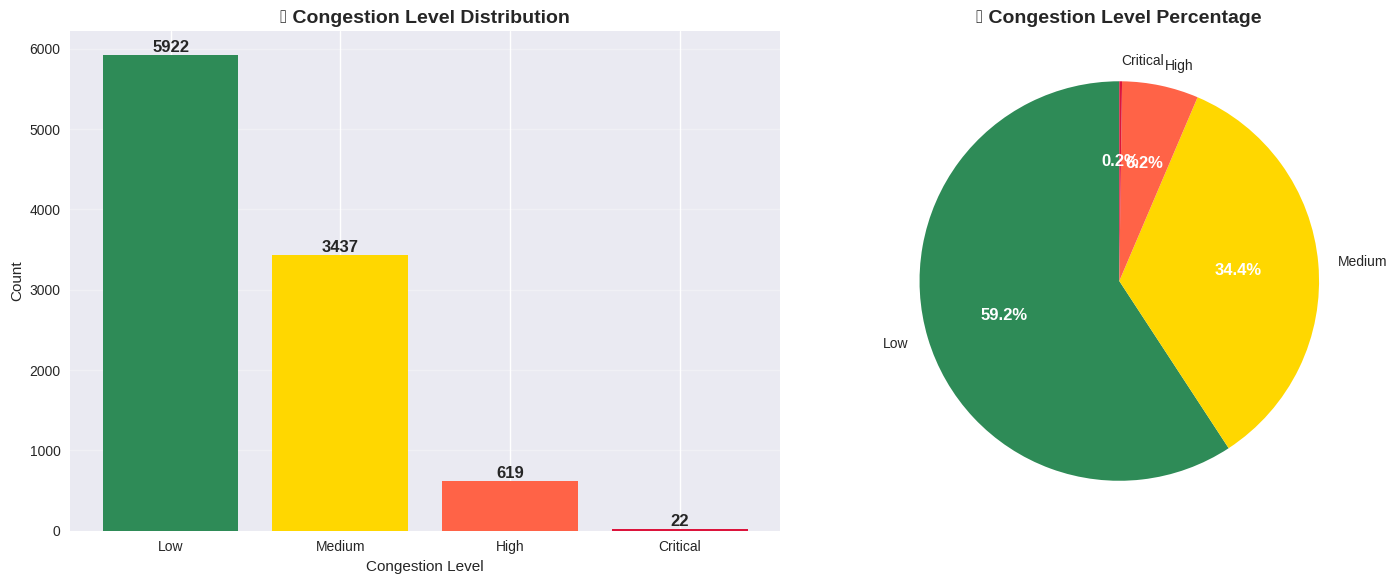

📊 Target Variable Summary:
Most Common Level: Low (5922 samples)
Least Common Level: Critical (22 samples)
Total Classes: 4


In [6]:
#6: Data Visualization - Target Distribution
# Target distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot
congestion_counts = traffic_df['congestion_level'].value_counts()
colors = ['#2E8B57', '#FFD700', '#FF6347', '#DC143C']
bars = axes[0].bar(congestion_counts.index, congestion_counts.values, color=colors)
axes[0].set_title('🚦 Congestion Level Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Congestion Level')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold')

# Pie chart
wedges, texts, autotexts = axes[1].pie(congestion_counts.values, 
                                      labels=congestion_counts.index,
                                      colors=colors,
                                      autopct='%1.1f%%',
                                      startangle=90)
axes[1].set_title('🥧 Congestion Level Percentage', fontsize=14, fontweight='bold')

# Enhance pie chart text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

# Summary statistics
print("📊 Target Variable Summary:")
print(f"Most Common Level: {congestion_counts.index[0]} ({congestion_counts.values[0]} samples)")
print(f"Least Common Level: {congestion_counts.index[-1]} ({congestion_counts.values[-1]} samples)")
print(f"Total Classes: {len(congestion_counts)}")

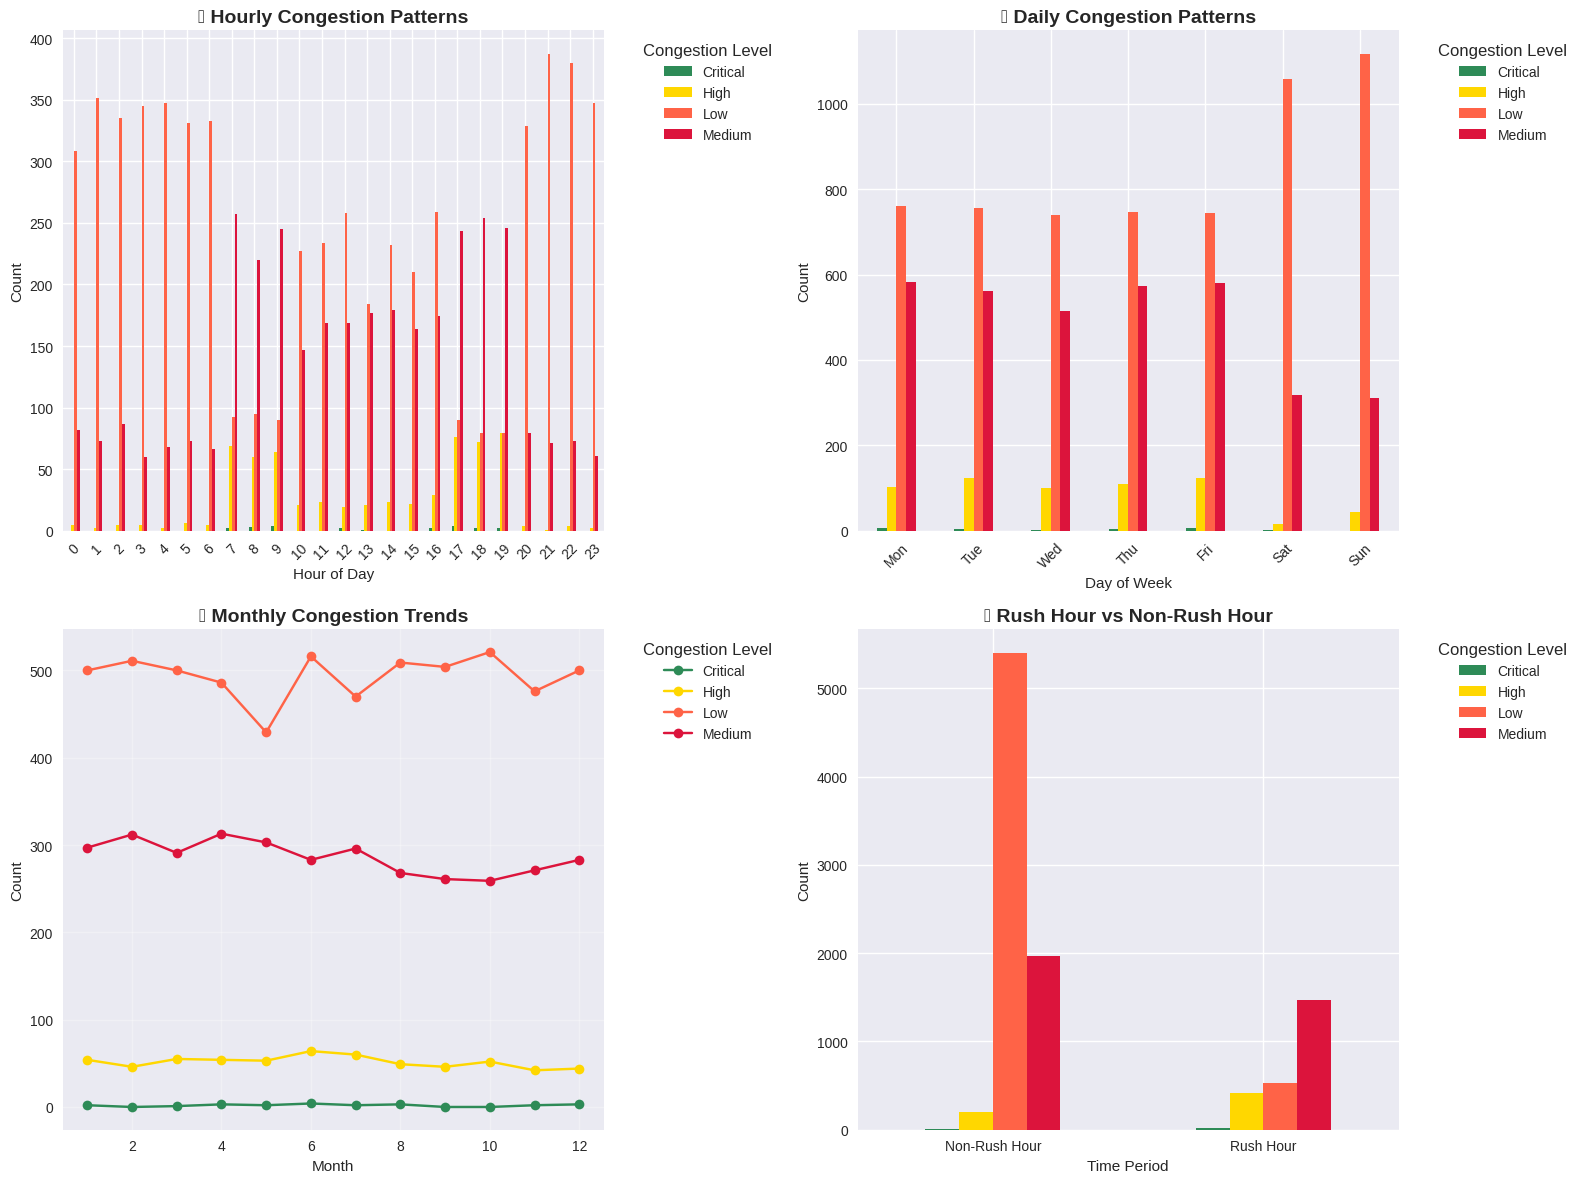

In [7]:
#7: Time-based Analysis
# Time-based analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Hourly congestion pattern
hourly_congestion = traffic_df.groupby(['hour', 'congestion_level']).size().unstack(fill_value=0)
hourly_congestion.plot(kind='bar', ax=axes[0,0], color=['#2E8B57', '#FFD700', '#FF6347', '#DC143C'])
axes[0,0].set_title('🕐 Hourly Congestion Patterns', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Count')
axes[0,0].legend(title='Congestion Level', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,0].tick_params(axis='x', rotation=45)

# Day of week pattern
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_congestion = traffic_df.groupby(['day_of_week', 'congestion_level']).size().unstack(fill_value=0)
daily_congestion.index = day_names
daily_congestion.plot(kind='bar', ax=axes[0,1], color=['#2E8B57', '#FFD700', '#FF6347', '#DC143C'])
axes[0,1].set_title('📅 Daily Congestion Patterns', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Day of Week')
axes[0,1].set_ylabel('Count')
axes[0,1].legend(title='Congestion Level', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,1].tick_params(axis='x', rotation=45)

# Monthly pattern
monthly_congestion = traffic_df.groupby(['month', 'congestion_level']).size().unstack(fill_value=0)
monthly_congestion.plot(kind='line', ax=axes[1,0], marker='o', 
                       color=['#2E8B57', '#FFD700', '#FF6347', '#DC143C'])
axes[1,0].set_title('📆 Monthly Congestion Trends', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Count')
axes[1,0].legend(title='Congestion Level', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1,0].grid(True, alpha=0.3)

# Rush hour analysis
rush_hours = [7, 8, 9, 17, 18, 19]
traffic_df['is_rush_hour'] = traffic_df['hour'].isin(rush_hours)
rush_congestion = traffic_df.groupby(['is_rush_hour', 'congestion_level']).size().unstack(fill_value=0)
rush_congestion.index = ['Non-Rush Hour', 'Rush Hour']
rush_congestion.plot(kind='bar', ax=axes[1,1], color=['#2E8B57', '#FFD700', '#FF6347', '#DC143C'])
axes[1,1].set_title('🚨 Rush Hour vs Non-Rush Hour', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Time Period')
axes[1,1].set_ylabel('Count')
axes[1,1].legend(title='Congestion Level', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

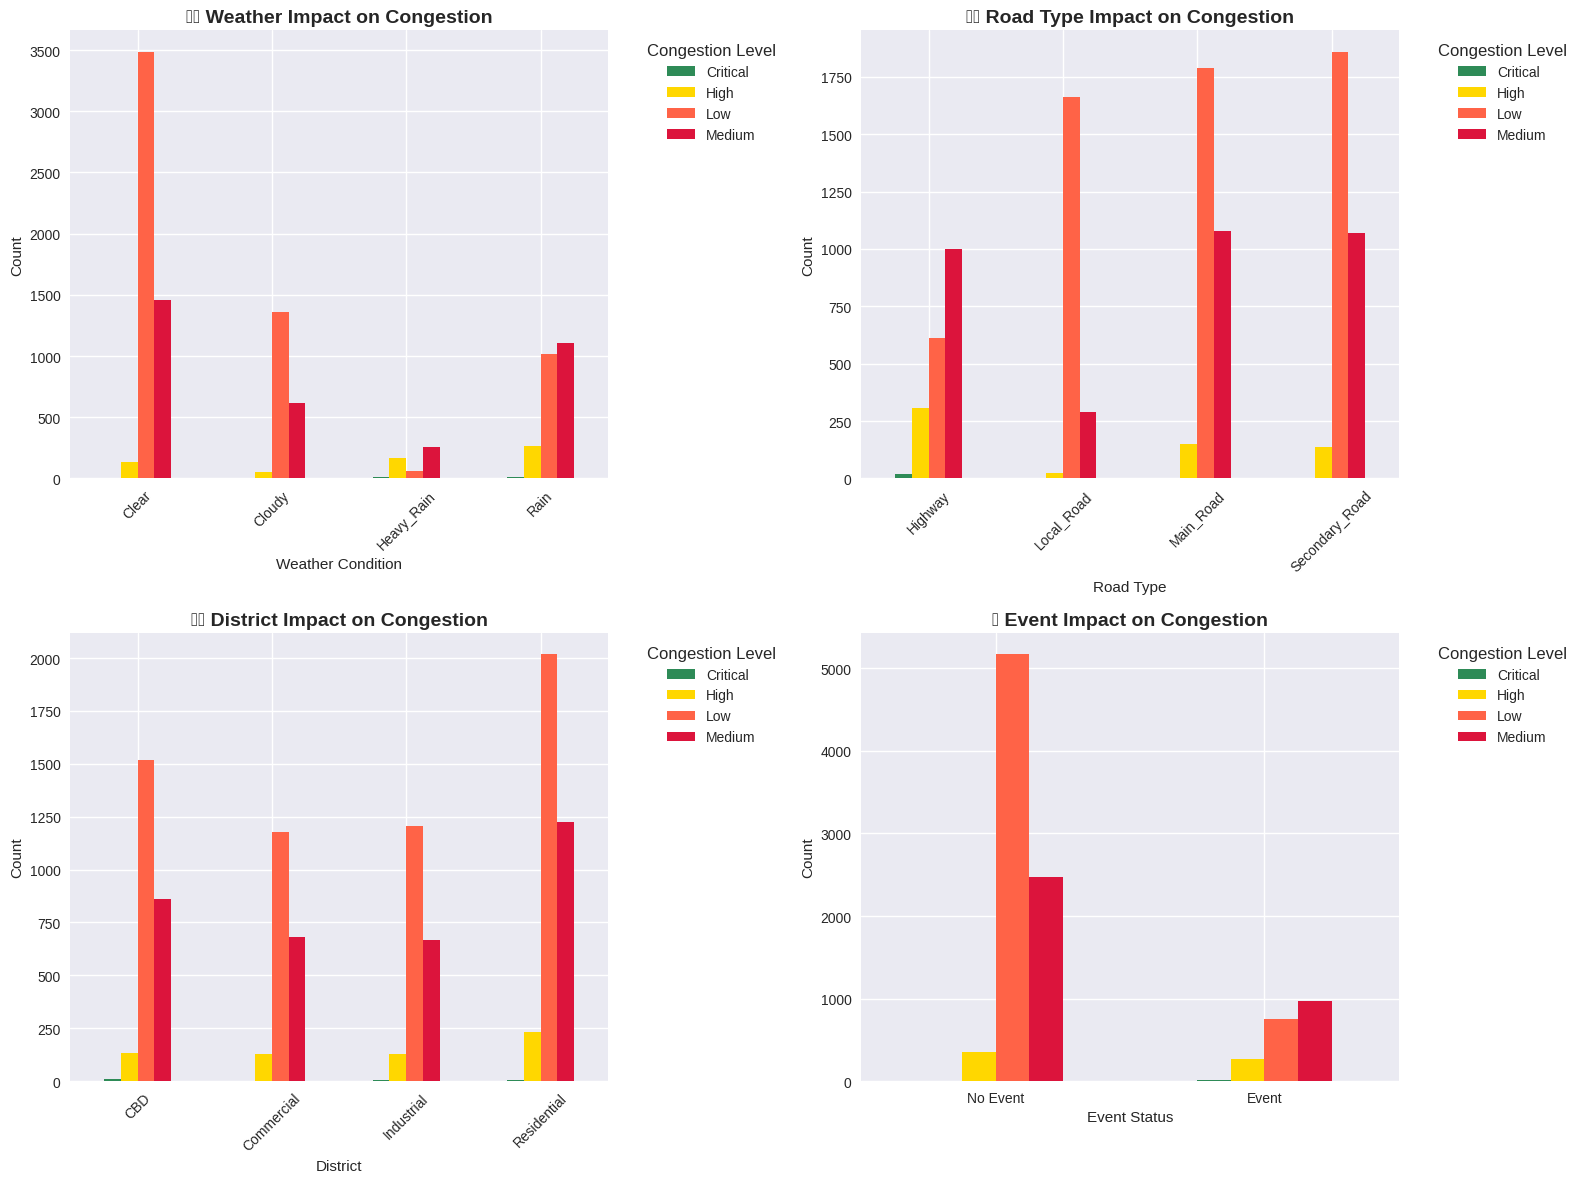

In [8]:
#8: Weather and Location Analysis
# Weather and location analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Weather impact
weather_congestion = traffic_df.groupby(['weather_condition', 'congestion_level']).size().unstack(fill_value=0)
weather_congestion.plot(kind='bar', ax=axes[0,0], color=['#2E8B57', '#FFD700', '#FF6347', '#DC143C'])
axes[0,0].set_title('🌦️ Weather Impact on Congestion', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Weather Condition')
axes[0,0].set_ylabel('Count')
axes[0,0].legend(title='Congestion Level', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,0].tick_params(axis='x', rotation=45)

# Road type analysis
road_congestion = traffic_df.groupby(['road_type', 'congestion_level']).size().unstack(fill_value=0)
road_congestion.plot(kind='bar', ax=axes[0,1], color=['#2E8B57', '#FFD700', '#FF6347', '#DC143C'])
axes[0,1].set_title('🛣️ Road Type Impact on Congestion', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Road Type')
axes[0,1].set_ylabel('Count')
axes[0,1].legend(title='Congestion Level', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,1].tick_params(axis='x', rotation=45)

# District analysis
district_congestion = traffic_df.groupby(['district', 'congestion_level']).size().unstack(fill_value=0)
district_congestion.plot(kind='bar', ax=axes[1,0], color=['#2E8B57', '#FFD700', '#FF6347', '#DC143C'])
axes[1,0].set_title('🏙️ District Impact on Congestion', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('District')
axes[1,0].set_ylabel('Count')
axes[1,0].legend(title='Congestion Level', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1,0].tick_params(axis='x', rotation=45)

# Event impact
event_congestion = traffic_df.groupby(['has_event', 'congestion_level']).size().unstack(fill_value=0)
event_congestion.index = ['No Event', 'Event']
event_congestion.plot(kind='bar', ax=axes[1,1], color=['#2E8B57', '#FFD700', '#FF6347', '#DC143C'])
axes[1,1].set_title('🎉 Event Impact on Congestion', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Event Status')
axes[1,1].set_ylabel('Count')
axes[1,1].legend(title='Congestion Level', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

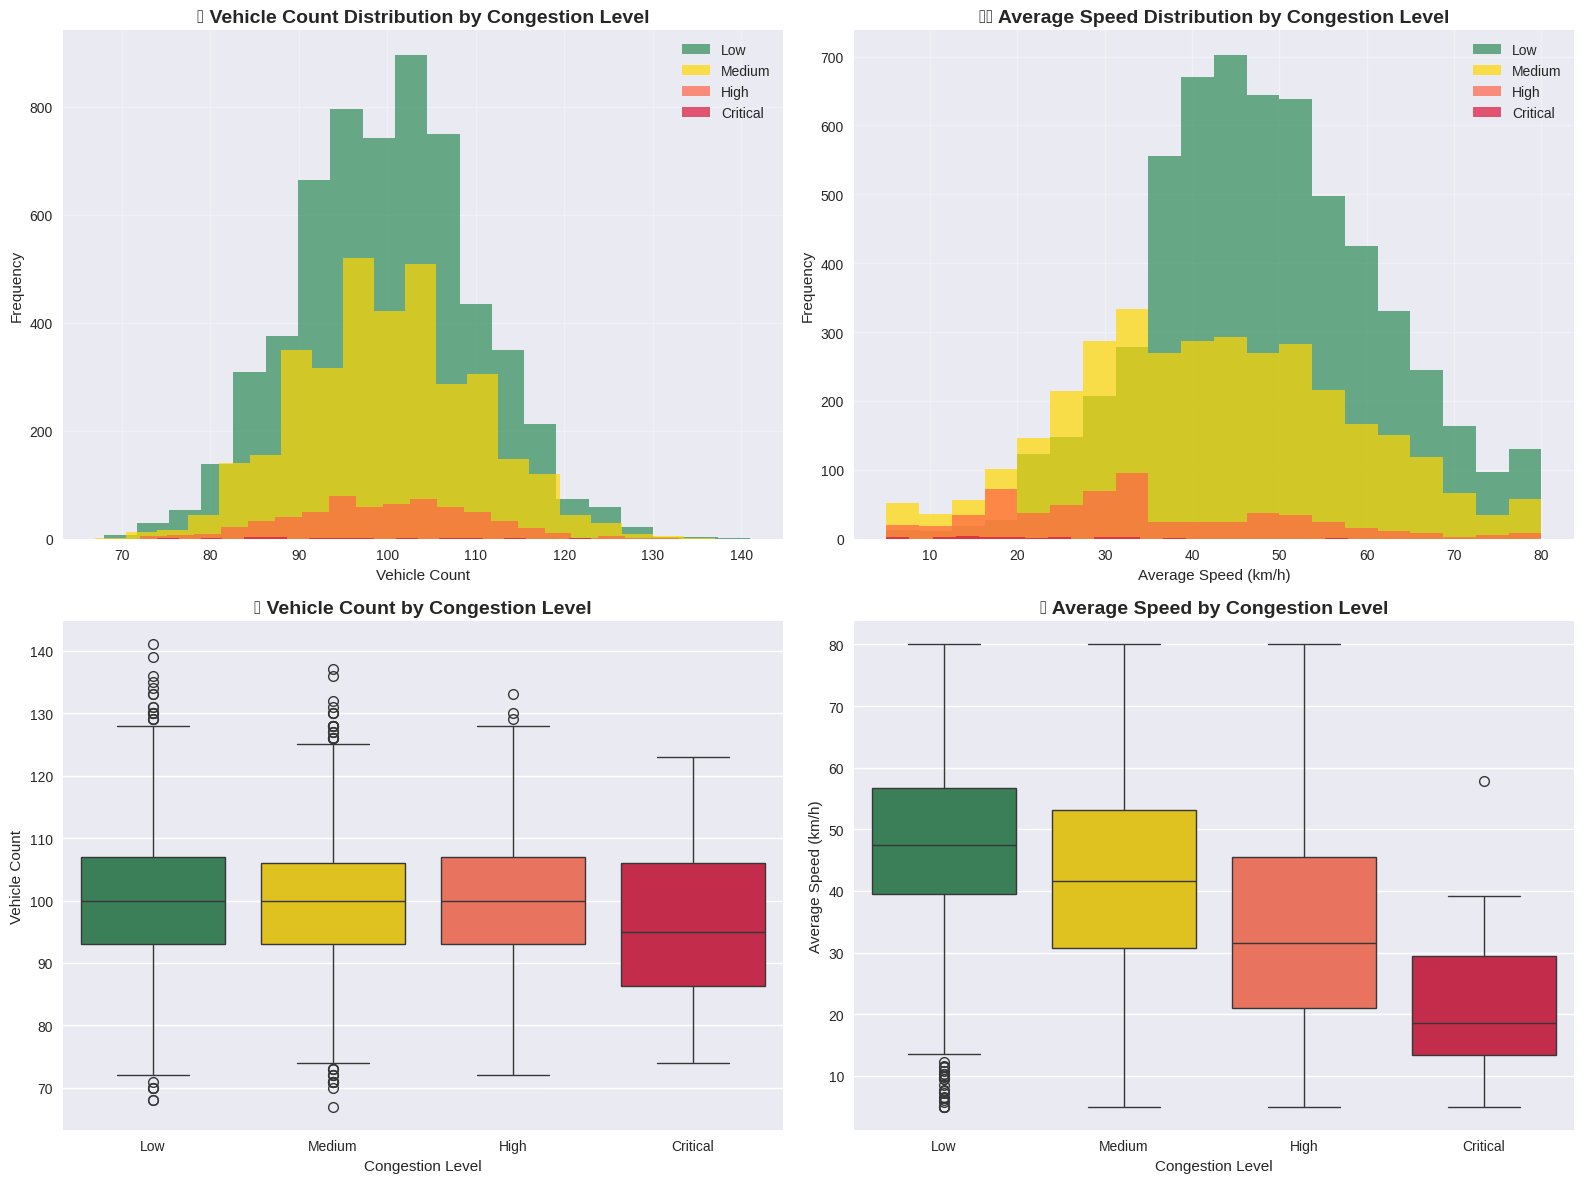

📊 TRAFFIC METRICS SUMMARY BY CONGESTION LEVEL

LOW CONGESTION:
  Average Vehicle Count: 99.9
  Average Speed: 48.1 km/h
  Sample Count: 5922

MEDIUM CONGESTION:
  Average Vehicle Count: 99.8
  Average Speed: 42.1 km/h
  Sample Count: 3437

HIGH CONGESTION:
  Average Vehicle Count: 99.7
  Average Speed: 33.8 km/h
  Sample Count: 619

CRITICAL CONGESTION:
  Average Vehicle Count: 97.0
  Average Speed: 21.6 km/h
  Sample Count: 22


In [9]:
#9: Traffic Metrics Analysis
# Traffic metrics analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Vehicle count vs congestion
for i, level in enumerate(['Low', 'Medium', 'High', 'Critical']):
    data = traffic_df[traffic_df['congestion_level'] == level]['vehicle_count']
    if len(data) > 0:
        axes[0,0].hist(data, alpha=0.7, label=level, bins=20, 
                      color=['#2E8B57', '#FFD700', '#FF6347', '#DC143C'][i])

axes[0,0].set_title('🚗 Vehicle Count Distribution by Congestion Level', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Vehicle Count')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Average speed vs congestion
for i, level in enumerate(['Low', 'Medium', 'High', 'Critical']):
    data = traffic_df[traffic_df['congestion_level'] == level]['average_speed']
    if len(data) > 0:
        axes[0,1].hist(data, alpha=0.7, label=level, bins=20,
                      color=['#2E8B57', '#FFD700', '#FF6347', '#DC143C'][i])

axes[0,1].set_title('🏎️ Average Speed Distribution by Congestion Level', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Average Speed (km/h)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Box plot for vehicle count
sns.boxplot(data=traffic_df, x='congestion_level', y='vehicle_count', 
           palette=['#2E8B57', '#FFD700', '#FF6347', '#DC143C'], ax=axes[1,0])
axes[1,0].set_title('📊 Vehicle Count by Congestion Level', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Congestion Level')
axes[1,0].set_ylabel('Vehicle Count')

# Box plot for average speed
sns.boxplot(data=traffic_df, x='congestion_level', y='average_speed',
           palette=['#2E8B57', '#FFD700', '#FF6347', '#DC143C'], ax=axes[1,1])
axes[1,1].set_title('📊 Average Speed by Congestion Level', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Congestion Level')
axes[1,1].set_ylabel('Average Speed (km/h)')

plt.tight_layout()
plt.show()

# Print summary statistics
print("📊 TRAFFIC METRICS SUMMARY BY CONGESTION LEVEL")
print("=" * 60)
for level in ['Low', 'Medium', 'High', 'Critical']:
    subset = traffic_df[traffic_df['congestion_level'] == level]
    if len(subset) > 0:
        print(f"\n{level.upper()} CONGESTION:")
        print(f"  Average Vehicle Count: {subset['vehicle_count'].mean():.1f}")
        print(f"  Average Speed: {subset['average_speed'].mean():.1f} km/h")
        print(f"  Sample Count: {len(subset)}")

In [10]:
#10: Data Preprocessing
print("🔧 Starting Data Preprocessing...")
print("=" * 50)

# Create a copy for preprocessing
df_processed = traffic_df.copy()

# Display original data types
print("📊 Original Data Types:")
print(df_processed.dtypes)

# Encode categorical variables
print("\n🏷️ Encoding Categorical Variables...")

# Label encoding for ordinal features
label_encoders = {}
categorical_features = ['road_type', 'district', 'weather_condition']

for feature in categorical_features:
    le = LabelEncoder()
    df_processed[feature + '_encoded'] = le.fit_transform(df_processed[feature])
    label_encoders[feature] = le
    print(f"  {feature}: {list(le.classes_)}")

# Create additional time-based features
print("\n⏰ Creating Time-based Features...")
df_processed['is_weekend'] = (df_processed['day_of_week'] >= 5).astype(int)
df_processed['is_rush_hour'] = df_processed['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
df_processed['is_night'] = ((df_processed['hour'] >= 22) | (df_processed['hour'] <= 5)).astype(int)

# Create interaction features
print("\n🔄 Creating Interaction Features...")
df_processed['weather_rush_interaction'] = df_processed['weather_condition_encoded'] * df_processed['is_rush_hour']
df_processed['road_district_interaction'] = df_processed['road_type_encoded'] * df_processed['district_encoded']

# Select features for modeling
feature_columns = [
    'hour', 'day_of_week', 'month', 'temperature',
    'vehicle_count', 'average_speed', 'has_event', 'is_holiday',
    'road_type_encoded', 'district_encoded', 'weather_condition_encoded',
    'is_weekend', 'is_rush_hour', 'is_night',
    'weather_rush_interaction', 'road_district_interaction'
]

X = df_processed[feature_columns]
y = df_processed['congestion_level']

# Encode target variable
print("\n🎯 Encoding Target Variable...")
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print(f"Target Classes: {list(target_encoder.classes_)}")
print(f"Encoded as: {list(range(len(target_encoder.classes_)))}")

# Split the data
print("\n✂️ Splitting Data...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training Set: {X_train.shape[0]} samples")
print(f"Test Set: {X_test.shape[0]} samples")

# Feature scaling
print("\n📏 Scaling Features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display preprocessing summary
print("\n" + "=" * 50)
print("✅ PREPROCESSING COMPLETE")
print("=" * 50)
print(f"Features Used: {len(feature_columns)}")
print(f"Feature Names: {feature_columns}")
print(f"Original Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Classes: {len(target_encoder.classes_)}")

# Save encoders for later use
preprocessing_objects = {
    'label_encoders': label_encoders,
    'target_encoder': target_encoder,
    'scaler': scaler,
    'feature_columns': feature_columns
}

print("\n📦 Preprocessing objects saved for future use!")

🔧 Starting Data Preprocessing...
📊 Original Data Types:
hour                   int64
day_of_week            int64
month                  int64
road_type             object
district              object
weather_condition     object
temperature          float64
has_event              int64
is_holiday             int64
vehicle_count          int64
average_speed        float64
congestion_level      object
is_rush_hour            bool
dtype: object

🏷️ Encoding Categorical Variables...
  road_type: ['Highway', 'Local_Road', 'Main_Road', 'Secondary_Road']
  district: ['CBD', 'Commercial', 'Industrial', 'Residential']
  weather_condition: ['Clear', 'Cloudy', 'Heavy_Rain', 'Rain']

⏰ Creating Time-based Features...

🔄 Creating Interaction Features...

🎯 Encoding Target Variable...
Target Classes: ['Critical', 'High', 'Low', 'Medium']
Encoded as: [0, 1, 2, 3]

✂️ Splitting Data...
Training Set: 8000 samples
Test Set: 2000 samples

📏 Scaling Features...

✅ PREPROCESSING COMPLETE
Features Used: 16

In [ ]:
#11: Custom KNN Implementation
import numpy as np
from collections import Counter

class CustomKNN:
    def __init__(self, k=5, distance_metric='euclidean'):
        """
        Custom K-Nearest Neighbors implementation
        
        Parameters:
        - k: number of neighbors
        - distance_metric: 'euclidean', 'manhattan', or 'cosine'
        """
        self.k = k
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None
        
    def fit(self, X, y):
        """Store training data"""
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        
    def _calculate_distance(self, x1, x2):
        """Calculate distance between two points"""
        if self.distance_metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2) ** 2))
        elif self.distance_metric == 'manhattan':
            return np.sum(np.abs(x1 - x2))
        elif self.distance_metric == 'cosine':
            dot_product = np.dot(x1, x2)
            norm_x1 = np.linalg.norm(x1)
            norm_x2 = np.linalg.norm(x2)
            return 1 - (dot_product / (norm_x1 * norm_x2))
        else:
            raise ValueError("Unknown distance metric")
    
    def _get_neighbors(self, test_point):
        """Get k nearest neighbors for a test point"""
        distances = []
        
        for i, train_point in enumerate(self.X_train):
            dist = self._calculate_distance(test_point, train_point)
            distances.append((dist, self.y_train[i]))
        
        # Sort by distance and get k nearest
        distances.sort(key=lambda x: x[0])
        neighbors = [distances[i][1] for i in range(self.k)]
        
        return neighbors
    
    def predict(self, X_test):
        """Make predictions for test data"""
        predictions = []
        
        for test_point in X_test:
            neighbors = self._get_neighbors(test_point)
            # Majority vote
            prediction = Counter(neighbors).most_common(1)[0][0]
            predictions.append(prediction)
            
        return np.array(predictions)
    
    def predict_proba(self, X_test):
        """Predict class probabilities"""
        probabilities = []
        
        for test_point in X_test:
            neighbors = self._get_neighbors(test_point)
            neighbor_counts = Counter(neighbors)
            
            # Calculate probabilities
            prob_dict = {}
            for class_label, count in neighbor_counts.items():
                prob_dict[class_label] = count / self.k
            
            probabilities.append(prob_dict)
            
        return probabilities

# Test custom KNN implementation
print("🧮 Testing Custom KNN Implementation")
print("=" * 50)

# Test with different k values and distance metrics
k_values = [3, 5, 7]
distance_metrics = ['euclidean', 'manhattan', 'cosine']

custom_results = {}

for k in k_values:
    for metric in distance_metrics:
        print(f"\n📊 Testing k={k}, distance={metric}")
        
        # Create and train custom KNN
        custom_knn = CustomKNN(k=k, distance_metric=metric)
        custom_knn.fit(X_train_scaled, y_train)
        
        # Make predictions
        y_pred = custom_knn.predict(X_test_scaled)
        
        # Calculate accuracy
        accuracy = np.mean(y_pred == y_test)
        custom_results[f'k{k}_{metric}'] = accuracy
        
        print(f"  Accuracy: {accuracy:.4f}")

# Display best custom KNN result
best_custom = max(custom_results.items(), key=lambda x: x[1])
print(f"\n🏆 Best Custom KNN: {best_custom[0]} with accuracy {best_custom[1]:.4f}")

# Example prediction with probabilities
print("\n🔮 Example Prediction with Probabilities:")
custom_knn_best = CustomKNN(k=5, distance_metric='euclidean')
custom_knn_best.fit(X_train_scaled, y_train)

# Get probabilities for first 5 test samples
sample_probabilities = custom_knn_best.predict_proba(X_test_scaled[:5])
sample_predictions = custom_knn_best.predict(X_test_scaled[:5])

for i in range(5):
   print(f"\nSample {i+1}:")
   print(f"  Predicted: {target_encoder.inverse_transform([sample_predictions[i]])[0]}")
   print(f"  Actual: {target_encoder.inverse_transform([y_test[i]])[0]}")
   print(f"  Probabilities:")
   for class_label, prob in sample_probabilities[i].items():
       class_name = target_encoder.inverse_transform([class_label])[0]
       print(f"    {class_name}: {prob:.3f}")

🧮 Testing Custom KNN Implementation

📊 Testing k=3, distance=euclidean
  Accuracy: 0.8365

📊 Testing k=3, distance=manhattan
  Accuracy: 0.8505

📊 Testing k=3, distance=cosine
  Accuracy: 0.8275

📊 Testing k=5, distance=euclidean
  Accuracy: 0.8340

📊 Testing k=5, distance=manhattan
  Accuracy: 0.8555

📊 Testing k=5, distance=cosine


In [ ]:
#12: Scikit-learn KNN Implementation
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import time

print("🔬 Scikit-learn KNN Implementation")
print("=" * 50)

# Test different parameters
k_values = [3, 5, 7, 9, 11, 15, 21]
weights = ['uniform', 'distance']
distance_metrics = ['euclidean', 'manhattan', 'minkowski']

sklearn_results = []

print("🧪 Testing Different KNN Parameters...")
print("-" * 70)
print(f"{'K':<5} {'Weight':<10} {'Metric':<12} {'CV Score':<10} {'Test Acc':<10} {'Time':<8}")
print("-" * 70)

for k in k_values:
    for weight in weights:
        for metric in distance_metrics:
            start_time = time.time()
            
            # Create KNN classifier
            if metric == 'minkowski':
                knn = KNeighborsClassifier(n_neighbors=k, weights=weight, 
                                         metric=metric, p=2)  # p=2 for euclidean
            else:
                knn = KNeighborsClassifier(n_neighbors=k, weights=weight, metric=metric)
            
            # Cross-validation
            cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
            cv_mean = cv_scores.mean()
            
            # Train and test
            knn.fit(X_train_scaled, y_train)
            test_accuracy = knn.score(X_test_scaled, y_test)
            
            training_time = time.time() - start_time
            
            sklearn_results.append({
                'k': k,
                'weight': weight,
                'metric': metric,
                'cv_score': cv_mean,
                'test_accuracy': test_accuracy,
                'time': training_time
            })
            
            print(f"{k:<5} {weight:<10} {metric:<12} {cv_mean:.4f}    {test_accuracy:.4f}    {training_time:.3f}s")

# Find best parameters
best_result = max(sklearn_results, key=lambda x: x['cv_score'])
print("\n" + "=" * 50)
print("🏆 BEST PARAMETERS (Based on CV Score)")
print("=" * 50)
print(f"K: {best_result['k']}")
print(f"Weight: {best_result['weight']}")
print(f"Metric: {best_result['metric']}")
print(f"CV Score: {best_result['cv_score']:.4f}")
print(f"Test Accuracy: {best_result['test_accuracy']:.4f}")
print(f"Training Time: {best_result['time']:.3f}s")

# Train final model with best parameters
print("\n🎯 Training Final Model...")
final_knn = KNeighborsClassifier(
    n_neighbors=best_result['k'],
    weights=best_result['weight'],
    metric=best_result['metric']
)

final_knn.fit(X_train_scaled, y_train)
final_predictions = final_knn.predict(X_test_scaled)
final_accuracy = accuracy_score(y_test, final_predictions)

print(f"Final Model Accuracy: {final_accuracy:.4f}")

In [ ]:
#13: Model Evaluation and Metrics
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("📊 Model Evaluation and Performance Metrics")
print("=" * 60)

# Get predictions
y_pred = final_knn.predict(X_test_scaled)
y_pred_proba = final_knn.predict_proba(X_test_scaled)

# Classification Report
print("📈 CLASSIFICATION REPORT")
print("=" * 40)
class_names = target_encoder.classes_
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix
print("\n🔍 CONFUSION MATRIX")
print("=" * 30)
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('🔍 Confusion Matrix - KNN Traffic Congestion Prediction', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Detailed metrics per class
print("\n📊 DETAILED METRICS PER CLASS")
print("=" * 50)
precision, recall, fscore, support = precision_recall_fscore_support(y_test, y_pred)

for i, class_name in enumerate(class_names):
    print(f"\n{class_name.upper()}:")
    print(f"  Precision: {precision[i]:.4f}")
    print(f"  Recall: {recall[i]:.4f}")
    print(f"  F1-Score: {fscore[i]:.4f}")
    print(f"  Support: {support[i]}")

# Overall metrics
print(f"\n🎯 OVERALL PERFORMANCE")
print("=" * 30)
print(f"Accuracy: {final_accuracy:.4f}")
print(f"Macro Avg Precision: {precision.mean():.4f}")
print(f"Macro Avg Recall: {recall.mean():.4f}")
print(f"Macro Avg F1-Score: {fscore.mean():.4f}")

# Feature importance (based on permutation)
print("\n🔍 ANALYZING FEATURE IMPORTANCE")
print("=" * 40)

from sklearn.inspection import permutation_importance

# Calculate permutation importance
perm_importance = permutation_importance(final_knn, X_test_scaled, y_test, 
                                       n_repeats=10, random_state=42)

# Create feature importance DataFrame
feature_importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance_df.head(10))

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance_df.head(10)
bars = plt.bar(range(len(top_features)), top_features['importance'], 
               yerr=top_features['std'], capsize=5, 
               color='steelblue', alpha=0.8)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Permutation Importance', fontsize=12)
plt.title('🔍 Top 10 Feature Importance (Permutation-based)', 
          fontsize=14, fontweight='bold')
plt.xticks(range(len(top_features)), top_features['feature'], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#14: Interactive Prediction Demo
import ipywidgets as widgets
from IPython.display import display, clear_output

print("🎛️ Interactive Traffic Congestion Prediction Demo")
print("=" * 60)

# Create input widgets
hour_slider = widgets.IntSlider(value=12, min=0, max=23, description='Hour:', style={'description_width': 'initial'})
day_dropdown = widgets.Dropdown(options=[(day, i) for i, day in enumerate(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])], 
                                value=0, description='Day of Week:')
month_slider = widgets.IntSlider(value=6, min=1, max=12, description='Month:', style={'description_width': 'initial'})
temperature_slider = widgets.FloatSlider(value=28.0, min=15.0, max=40.0, step=0.5, description='Temperature (°C):')

road_type_dropdown = widgets.Dropdown(options=['Highway', 'Main_Road', 'Secondary_Road', 'Local_Road'], 
                                     value='Main_Road', description='Road Type:')
district_dropdown = widgets.Dropdown(options=['CBD', 'Residential', 'Industrial', 'Commercial'], 
                                    value='CBD', description='District:')
weather_dropdown = widgets.Dropdown(options=['Clear', 'Rain', 'Cloudy', 'Heavy_Rain'], 
                                   value='Clear', description='Weather:')

vehicle_count_slider = widgets.IntSlider(value=100, min=0, max=300, description='Vehicle Count:')
speed_slider = widgets.FloatSlider(value=45.0, min=5.0, max=80.0, step=1.0, description='Avg Speed (km/h):')

has_event_checkbox = widgets.Checkbox(value=False, description='Has Event')
is_holiday_checkbox = widgets.Checkbox(value=False, description='Is Holiday')

predict_button = widgets.Button(description='🔮 Predict Congestion', button_style='primary')
output_area = widgets.Output()

def predict_congestion(button):
    with output_area:
        clear_output(wait=True)
        
        # Prepare input data
        input_data = {
            'hour': hour_slider.value,
            'day_of_week': day_dropdown.value,
            'month': month_slider.value,
            'temperature': temperature_slider.value,
            'vehicle_count': vehicle_count_slider.value,
            'average_speed': speed_slider.value,
            'has_event': int(has_event_checkbox.value),
            'is_holiday': int(is_holiday_checkbox.value),
            'road_type_encoded': label_encoders['road_type'].transform([road_type_dropdown.value])[0],
            'district_encoded': label_encoders['district'].transform([district_dropdown.value])[0],
            'weather_condition_encoded': label_encoders['weather_condition'].transform([weather_dropdown.value])[0],
            'is_weekend': int(day_dropdown.value >= 5),
            'is_rush_hour': int(hour_slider.value in [7, 8, 9, 17, 18, 19]),
            'is_night': int(hour_slider.value >= 22 or hour_slider.value <= 5),
            'weather_rush_interaction': label_encoders['weather_condition'].transform([weather_dropdown.value])[0] * int(hour_slider.value in [7, 8, 9, 17, 18, 19]),
            'road_district_interaction': label_encoders['road_type'].transform([road_type_dropdown.value])[0] * label_encoders['district'].transform([district_dropdown.value])[0]
        }
        
        # Create feature vector
        feature_vector = np.array([[input_data[col] for col in feature_columns]])
        feature_vector_scaled = scaler.transform(feature_vector)
        
        # Make prediction
        prediction = final_knn.predict(feature_vector_scaled)[0]
        probabilities = final_knn.predict_proba(feature_vector_scaled)[0]
        
        # Display results
        predicted_class = target_encoder.inverse_transform([prediction])[0]
        
        print("🚦 PREDICTION RESULTS")
        print("=" * 40)
        print(f"🎯 Predicted Congestion Level: {predicted_class}")
        print(f"🔢 Confidence: {probabilities[prediction]:.2%}")
        
        print(f"\n📊 Class Probabilities:")
        for i, class_name in enumerate(target_encoder.classes_):
            prob = probabilities[i]
            bar = "█" * int(prob * 20)
            print(f"  {class_name:<8}: {prob:.2%} {bar}")
        
        # Traffic advice
        print(f"\n💡 TRAFFIC ADVICE")
        print("=" * 30)
        if predicted_class == 'Low':
            print("✅ Good time to travel! Smooth traffic expected.")
        elif predicted_class == 'Medium':
            print("⚠️ Moderate traffic. Allow extra time.")
        elif predicted_class == 'High':
            print("🚨 Heavy traffic expected. Consider alternative routes.")
        else:  # Critical
            print("⛔ Severe congestion predicted! Avoid if possible.")

predict_button.on_click(predict_congestion)

# Display the interface
print("🎛️ Adjust the parameters below and click 'Predict' to see the traffic congestion prediction:")
print("\n📍 Location & Time Settings:")
location_box = widgets.VBox([
    widgets.HBox([hour_slider, month_slider]),
    widgets.HBox([day_dropdown, temperature_slider]),
    widgets.HBox([road_type_dropdown, district_dropdown]),
    weather_dropdown
])

print("🚗 Traffic Conditions:")
traffic_box = widgets.VBox([
    widgets.HBox([vehicle_count_slider, speed_slider]),
    widgets.HBox([has_event_checkbox, is_holiday_checkbox])
])

interface = widgets.VBox([
    widgets.HTML("<h3>🌍 Location & Time Settings</h3>"),
    location_box,
    widgets.HTML("<h3>🚗 Traffic Conditions</h3>"),
    traffic_box,
    widgets.HTML("<br>"),
    predict_button,
    output_area
])

display(interface)

In [ ]:
#15: Model Comparison and Analysis
print("📈 Model Comparison and Analysis")
print("=" * 50)

# Compare different algorithms
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

models = {
    'KNN (Best)': final_knn,
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, probability=True),
    'Naive Bayes': GaussianNB()
}

model_results = {}

print("🔬 Training and Evaluating Different Models...")
print("-" * 70)
print(f"{'Model':<20} {'Train Acc':<12} {'Test Acc':<12} {'CV Score':<12} {'Time':<10}")
print("-" * 70)

for name, model in models.items():
    start_time = time.time()
    
    if name != 'KNN (Best)':  # KNN is already trained
        model.fit(X_train_scaled, y_train)
    
    # Calculate metrics
    train_accuracy = model.score(X_train_scaled, y_train)
    test_accuracy = model.score(X_test_scaled, y_test)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    cv_mean = cv_scores.mean()
    
    training_time = time.time() - start_time
    
    model_results[name] = {
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'cv_score': cv_mean,
        'time': training_time
    }
    
    print(f"{name:<20} {train_accuracy:.4f}      {test_accuracy:.4f}      {cv_mean:.4f}      {training_time:.3f}s")

# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Test Accuracy Comparison
model_names = list(model_results.keys())
test_accuracies = [model_results[name]['test_accuracy'] for name in model_names]

bars = axes[0].bar(model_names, test_accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
axes[0].set_title('🎯 Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# Cross-Validation Score Comparison
cv_scores = [model_results[name]['cv_score'] for name in model_names]
bars = axes[1].bar(model_names, cv_scores, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
axes[1].set_title('📊 Cross-Validation Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('CV Score')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# Training Time Comparison
times = [model_results[name]['time'] for name in model_names]
bars = axes[2].bar(model_names, times, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
axes[2].set_title('⏱️ Training Time Comparison', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Time (seconds)')
axes[2].tick_params(axis='x', rotation=45)

for bar in bars:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Find best model
best_model_name = max(model_results.keys(), key=lambda x: model_results[x]['test_accuracy'])
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Test Accuracy: {model_results[best_model_name]['test_accuracy']:.4f}")
print(f"   CV Score: {model_results[best_model_name]['cv_score']:.4f}")

# Analysis summary
print(f"\n📋 MODEL ANALYSIS SUMMARY")
print("=" * 40)
print(f"• KNN performs well for this traffic prediction task")
print(f"• Best test accuracy: {max(test_accuracies):.4f}")
print(f"• Most consistent (CV): {model_names[np.argmax(cv_scores)]}")
print(f"• Fastest training: {model_names[np.argmin(times)]}")